# Multi-Probe Measurement Visualization

This notebook reads a final `xdesi_multiprobe_measurement_v1` HDF5 product and plots most spectra as
`D_ell = ell(ell+1) C_ell / (2 pi)` with errorbars from the assembled joint covariance. DESI galaxy auto spectra
are plotted as total `C_ell` with the saved shot-noise bandpower added back, so they can be compared to the
published clustering measurement that includes shot noise. It also saves and displays the joint covariance,
correlation matrix, and covariance diagonal diagnostics.

To reuse this for `midres2048`, change `STAGE = "midres2048"` below or set `MEASUREMENT` to an explicit HDF5 path.

In [1]:
from pathlib import Path
import sys

ROOT = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX')
STAGE = 'fast1024'
MEASUREMENT = None  # set to an explicit .h5 path to override STAGE defaults
OUTPUT_DIR = None   # defaults to <measurement-dir>/diagnostics
PUBLISHED_GG_CLS = Path('/mnt/ceph/users/spandey/xdesi/lrg_xcorr_2023/v1/clustering/combined_cls.json')
PUBLISHED_GG_CLS_KEY = 'cls_ext'  # use cls_ext for the extended catalog; cls_fid is the fiducial LRG catalog

sys.path.insert(0, str(ROOT / 'notebooks/xDESI/survey_measure'))
from plot_multiprobe_measurement import (
    default_measurement_for_stage,
    load_measurement,
    make_all_plots,
    spectra_by_family,
)

if MEASUREMENT is None:
    MEASUREMENT = default_measurement_for_stage(STAGE, root=ROOT)
else:
    MEASUREMENT = Path(MEASUREMENT)

if OUTPUT_DIR is None:
    OUTPUT_DIR = MEASUREMENT.parent / 'diagnostics'
else:
    OUTPUT_DIR = Path(OUTPUT_DIR)

MEASUREMENT, OUTPUT_DIR

(PosixPath('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/xdesi_multiprobe_cls_cov_nside1024_lmax1024_nbin10_linear.h5'),
 PosixPath('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics'))

In [2]:
measurement = load_measurement(MEASUREMENT, stage_label=STAGE)
families = spectra_by_family(measurement)

print('measurement:', measurement.path)
print('schema:', measurement.schema)
print('stage:', measurement.stage)
print('n_spectra:', len(measurement.spectra))
print('n_ell:', len(measurement.ell))
print('covariance shape:', measurement.covariance.shape)
print('\nFamily counts:')
for family, spectra in families.items():
    print(f'  {family:24s} {len(spectra):2d}')

measurement: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/xdesi_multiprobe_cls_cov_nside1024_lmax1024_nbin10_linear.h5
schema: xdesi_multiprobe_measurement_v1
stage: fast1024
n_spectra: 46
n_ell: 10
covariance shape: (460, 460)

Family counts:
  des_shear_EE             10
  act_y_des_shear_E         4
  desi_g_auto               4
  desi_g_act_y              4
  desi_g_des_shear_E       16
  desi_g_act_kappa          4
  desi_pi_act_T             4


In [3]:
outputs = make_all_plots(MEASUREMENT, OUTPUT_DIR, stage_label=STAGE, published_gg_cls_path=PUBLISHED_GG_CLS, published_gg_cls_key=PUBLISHED_GG_CLS_KEY)
print(f'Wrote {len(outputs)} plot products to {OUTPUT_DIR}')
for path in outputs:
    print(path)

Wrote 11 plot products to /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_des_shear_EE_Dell.png
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_act_y_des_shear_E_Dell.png
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_desi_g_auto_Cell.png
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_desi_g_act_y_Dell.png
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_desi_g_des_shear_E_Dell.png
/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_desi_g_act_kappa_Dell.pn

In [4]:
from IPython.display import Image, Markdown, display

for path in outputs:
    display(Markdown(f'[{path.name}]({path})'))

[fast1024_spectra_des_shear_EE_Dell.png](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_des_shear_EE_Dell.png)

[fast1024_spectra_act_y_des_shear_E_Dell.png](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_act_y_des_shear_E_Dell.png)

[fast1024_spectra_desi_g_auto_Cell.png](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_desi_g_auto_Cell.png)

[fast1024_spectra_desi_g_act_y_Dell.png](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_desi_g_act_y_Dell.png)

[fast1024_spectra_desi_g_des_shear_E_Dell.png](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_desi_g_des_shear_E_Dell.png)

...

[fast1024_spectra_desi_pi_act_T_Dell.png](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_spectra_desi_pi_act_T_Dell.png)

[fast1024_all_spectra_Dell.pdf](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_all_spectra_Dell.pdf)

[fast1024_joint_covariance_matrix.png](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_joint_covariance_matrix.png)

[fast1024_joint_correlation_matrix.png](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_joint_correlation_matrix.png)

[fast1024_joint_covariance_diagonal_errors.png](/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/fast1024/diagnostics/fast1024_joint_covariance_diagonal_errors.png)

### fast1024_spectra_des_shear_EE_Dell.png

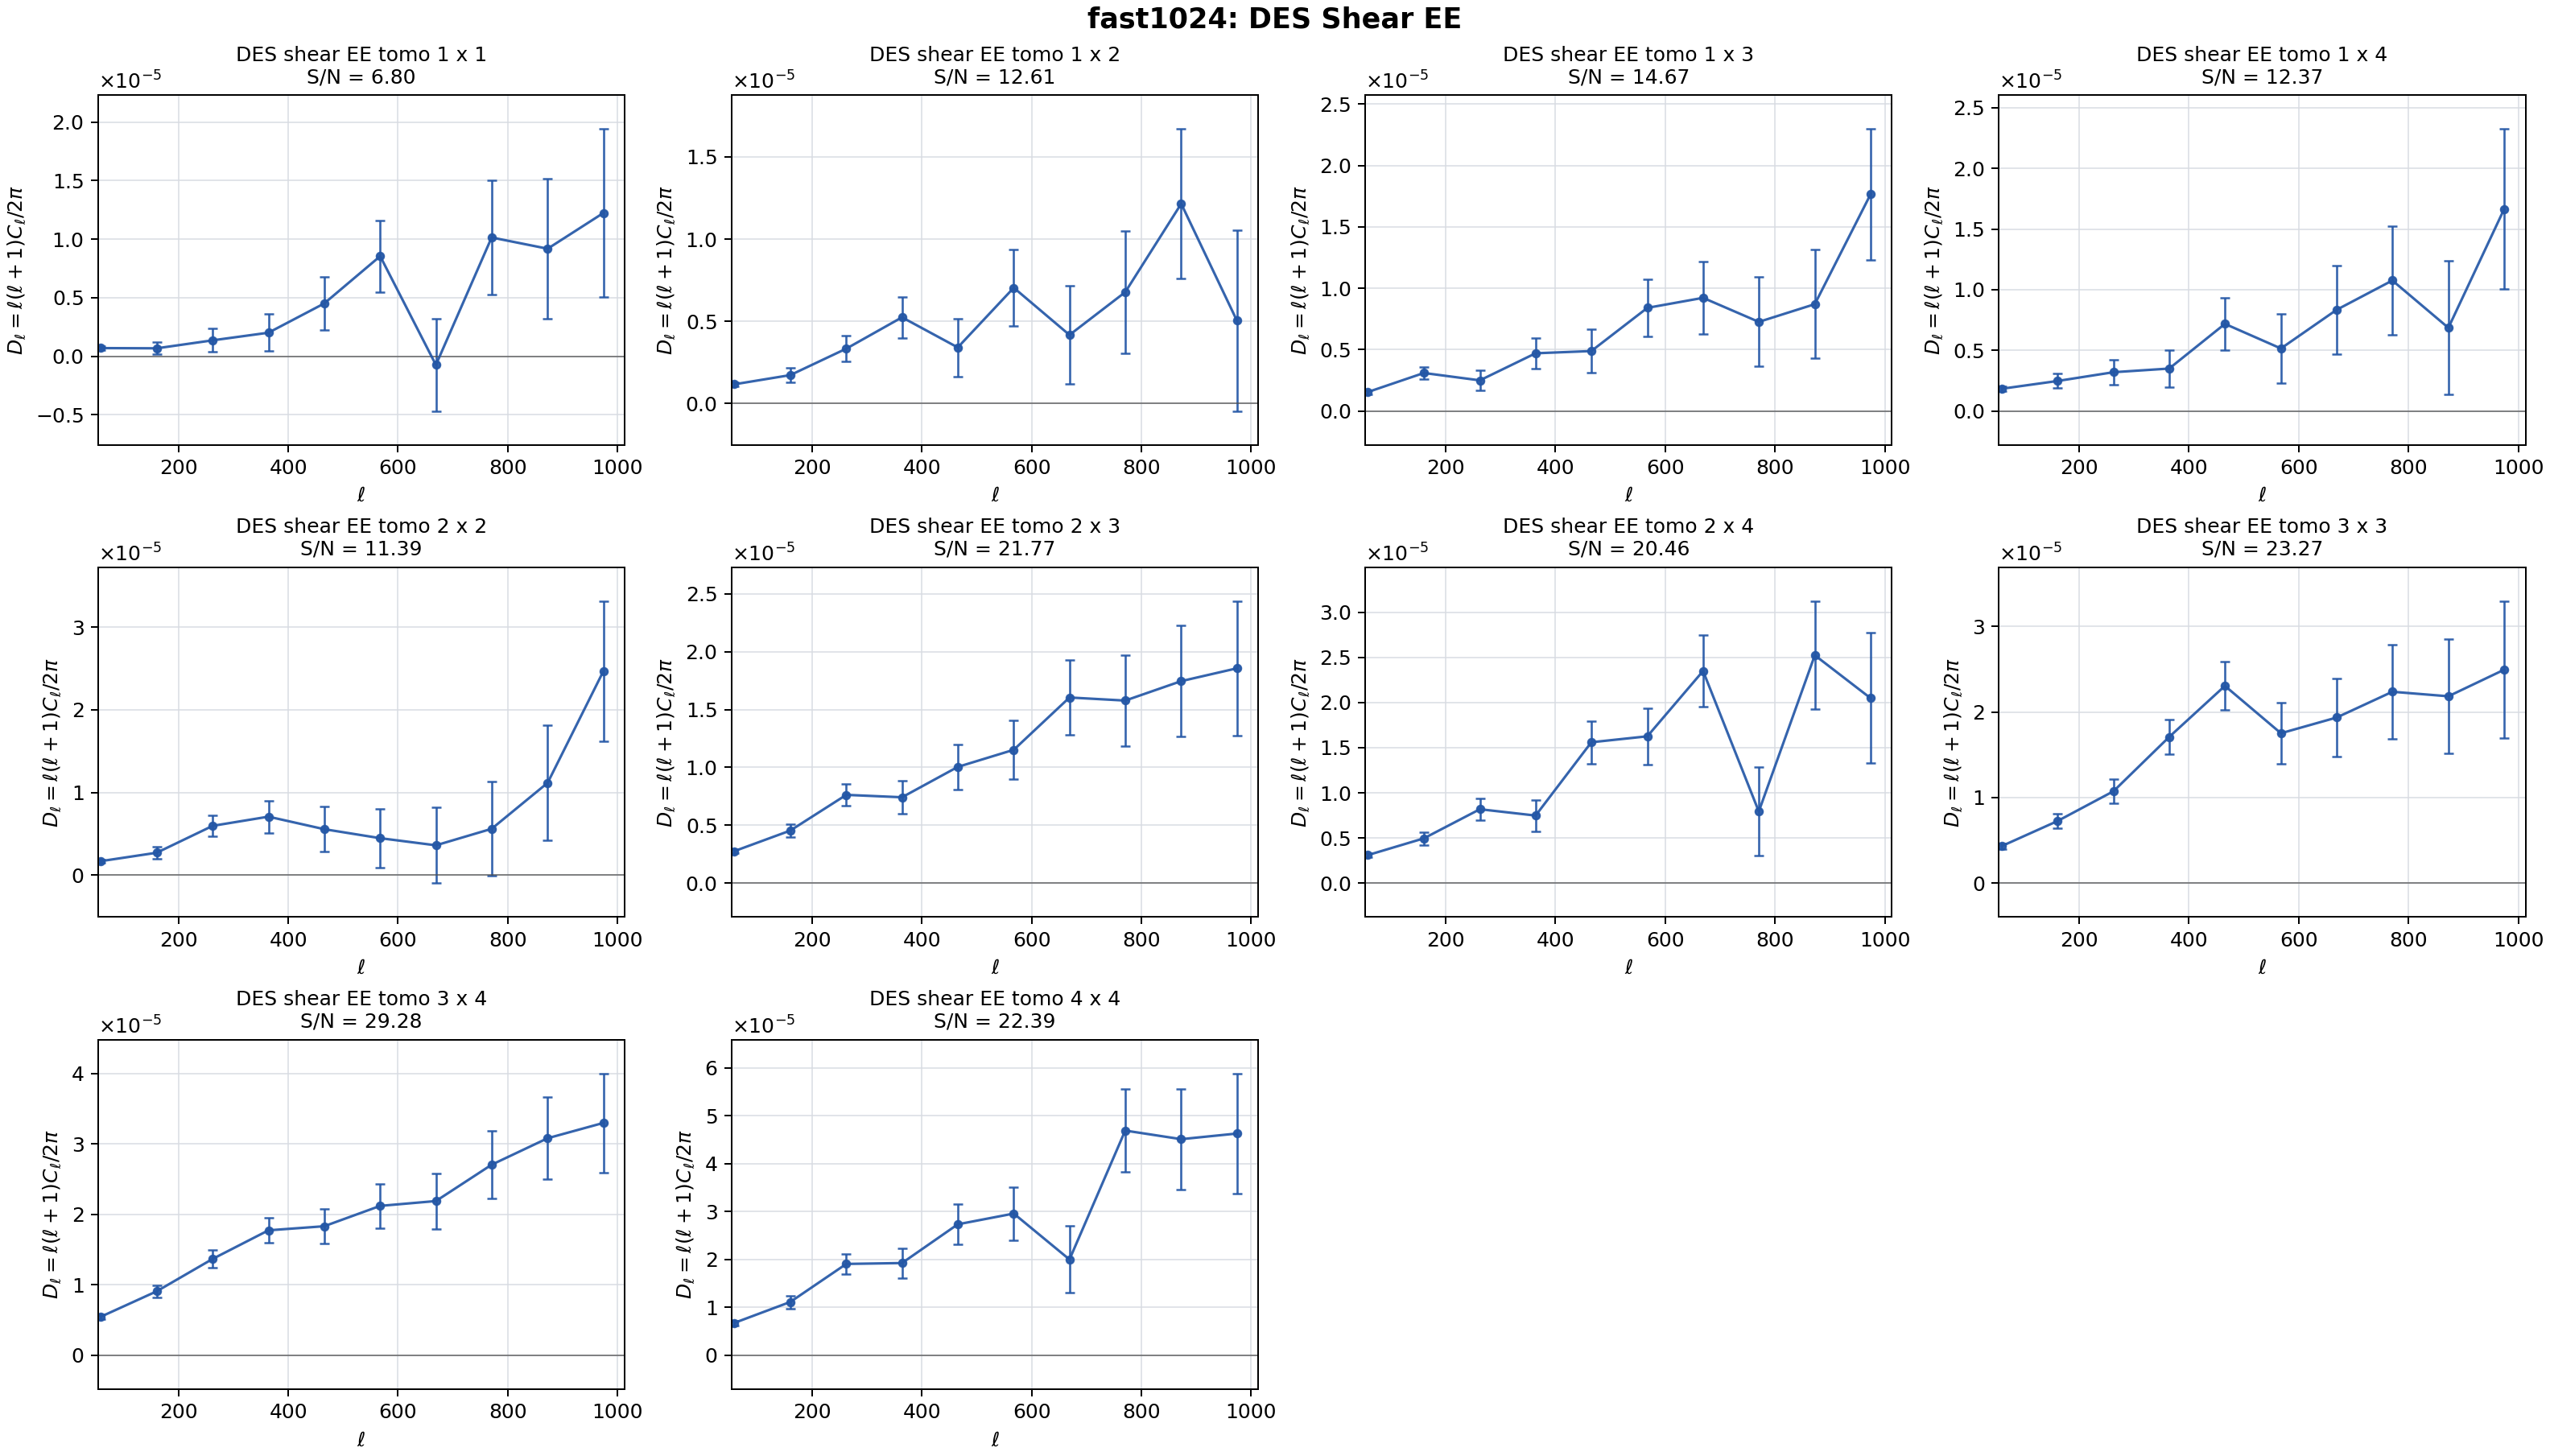

### fast1024_spectra_act_y_des_shear_E_Dell.png

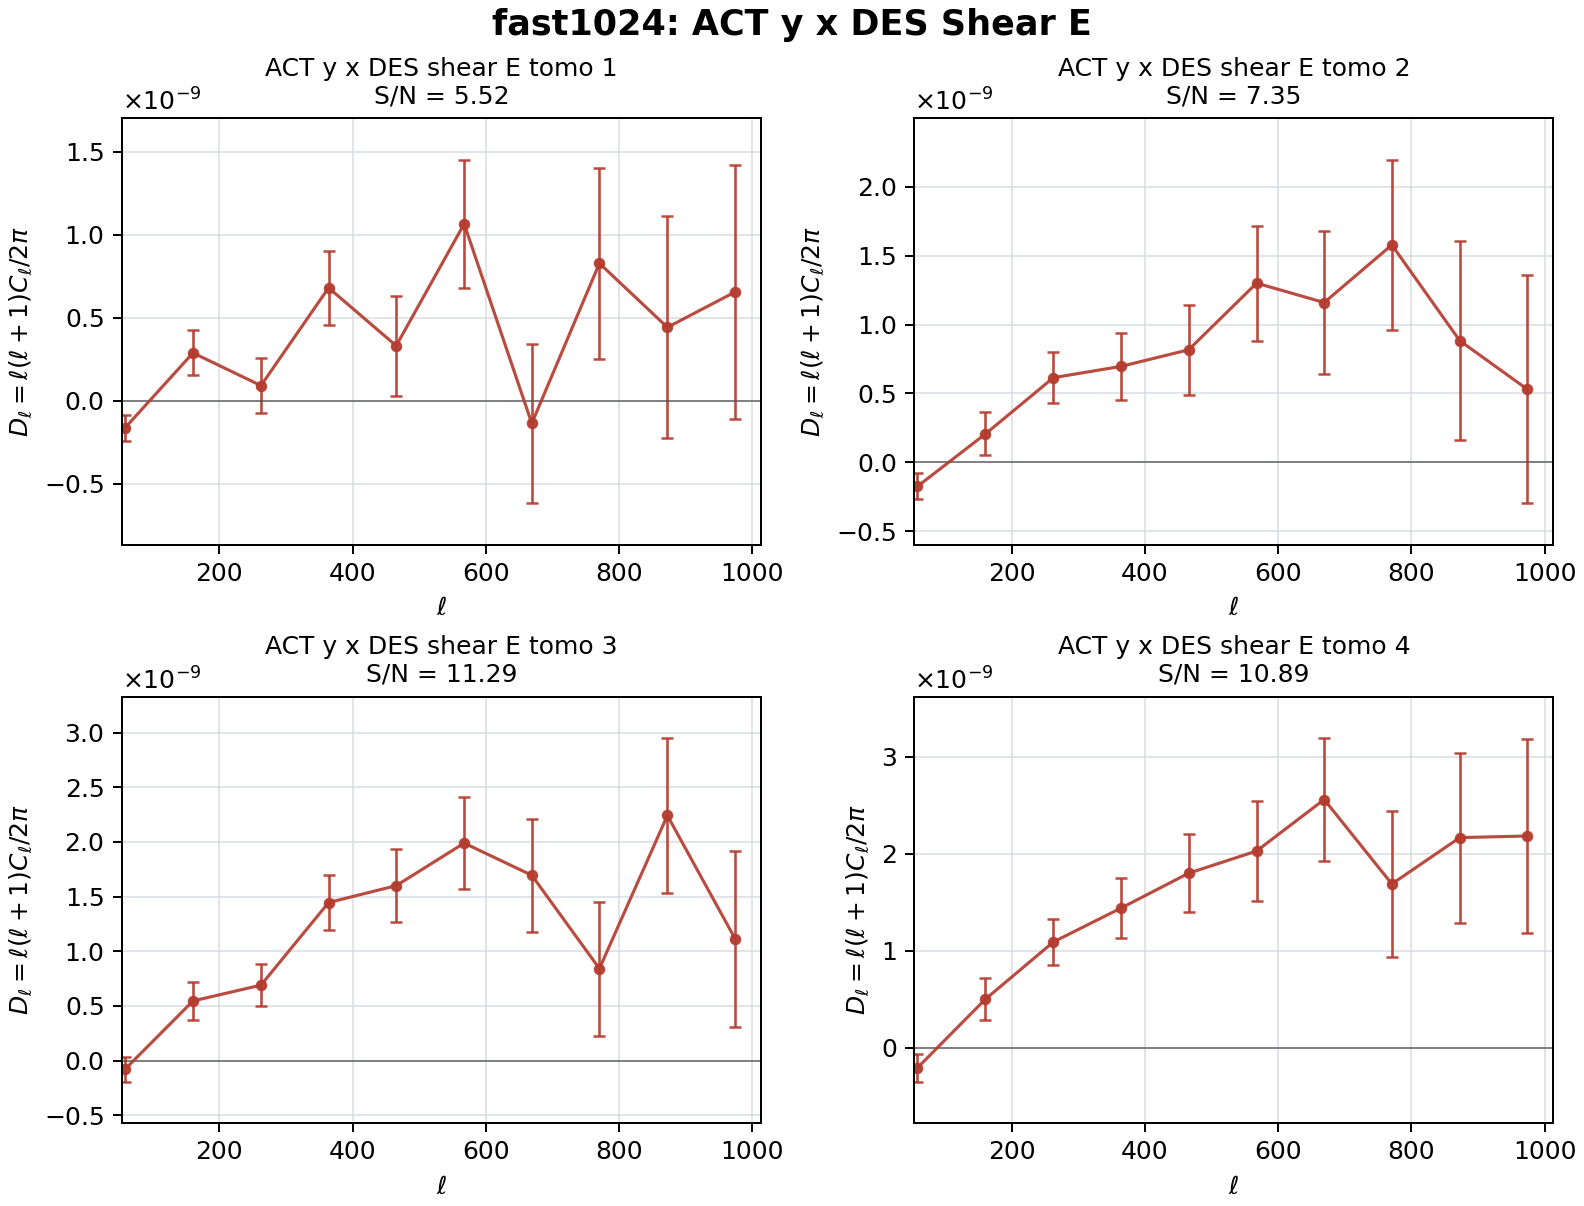

### fast1024_spectra_desi_g_auto_Cell.png

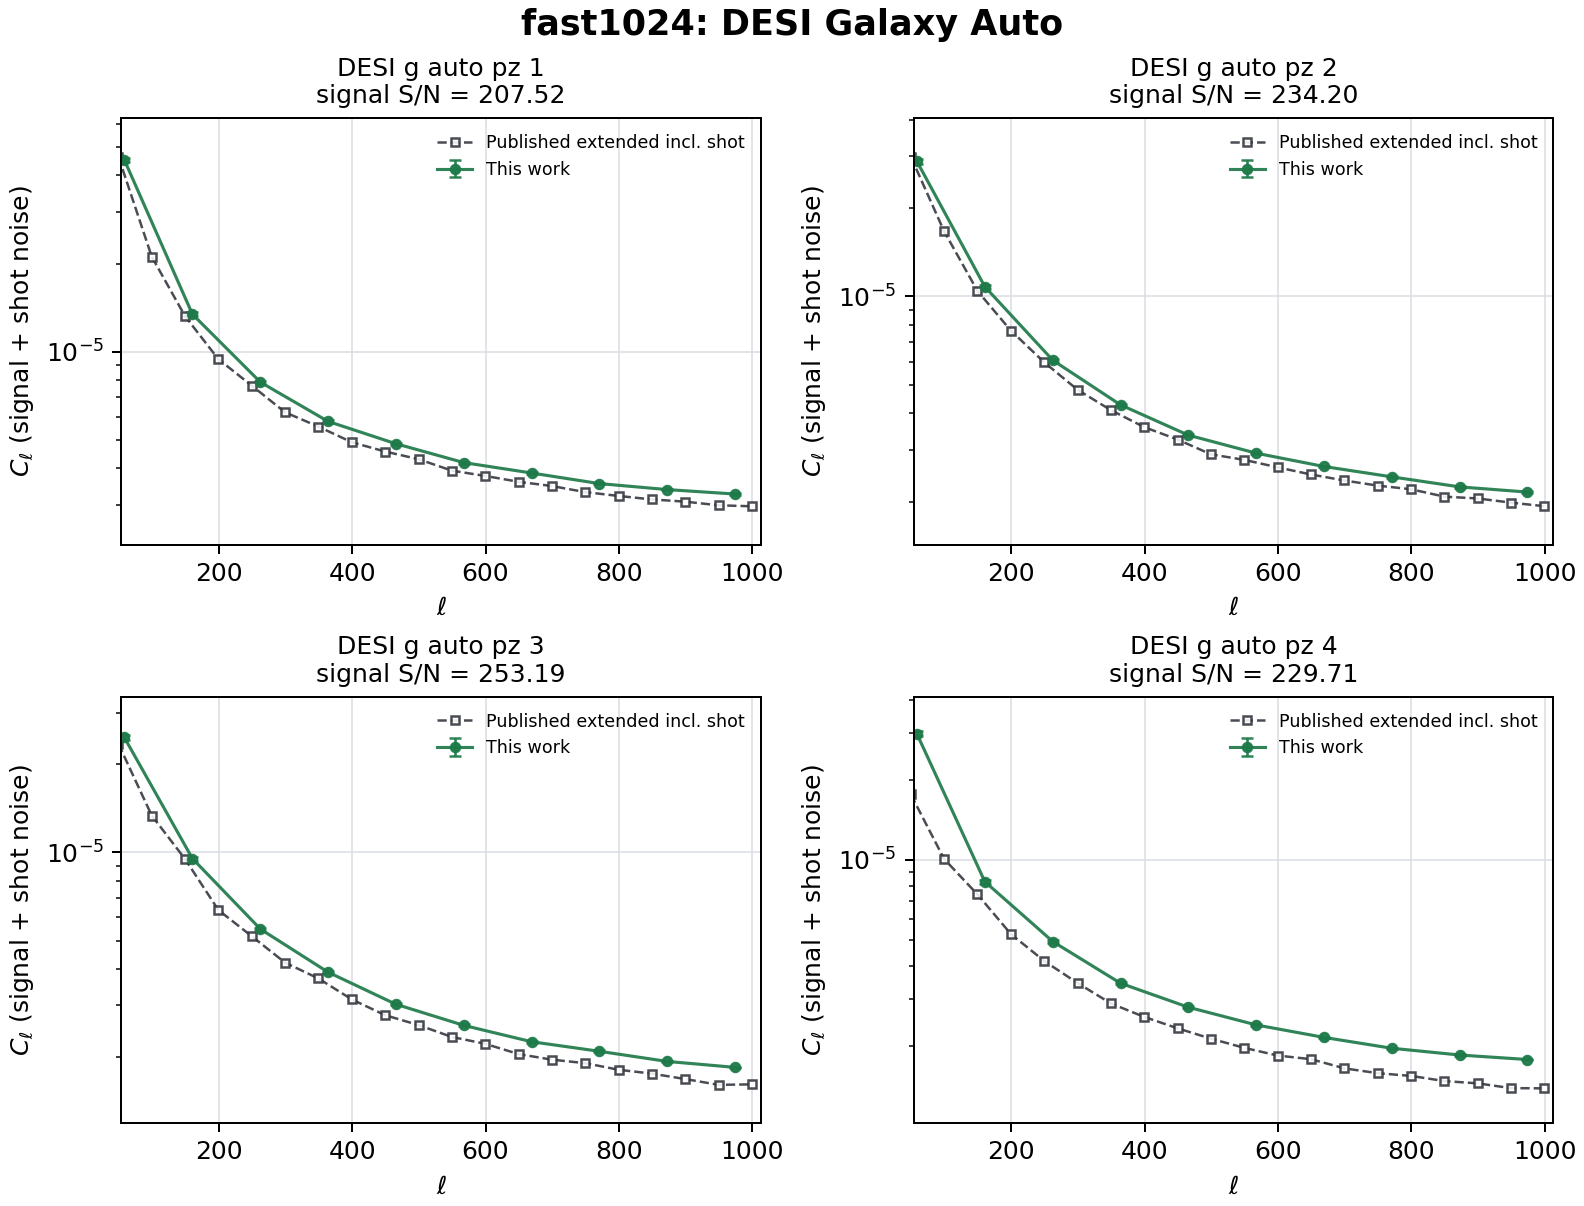

### fast1024_spectra_desi_g_act_y_Dell.png

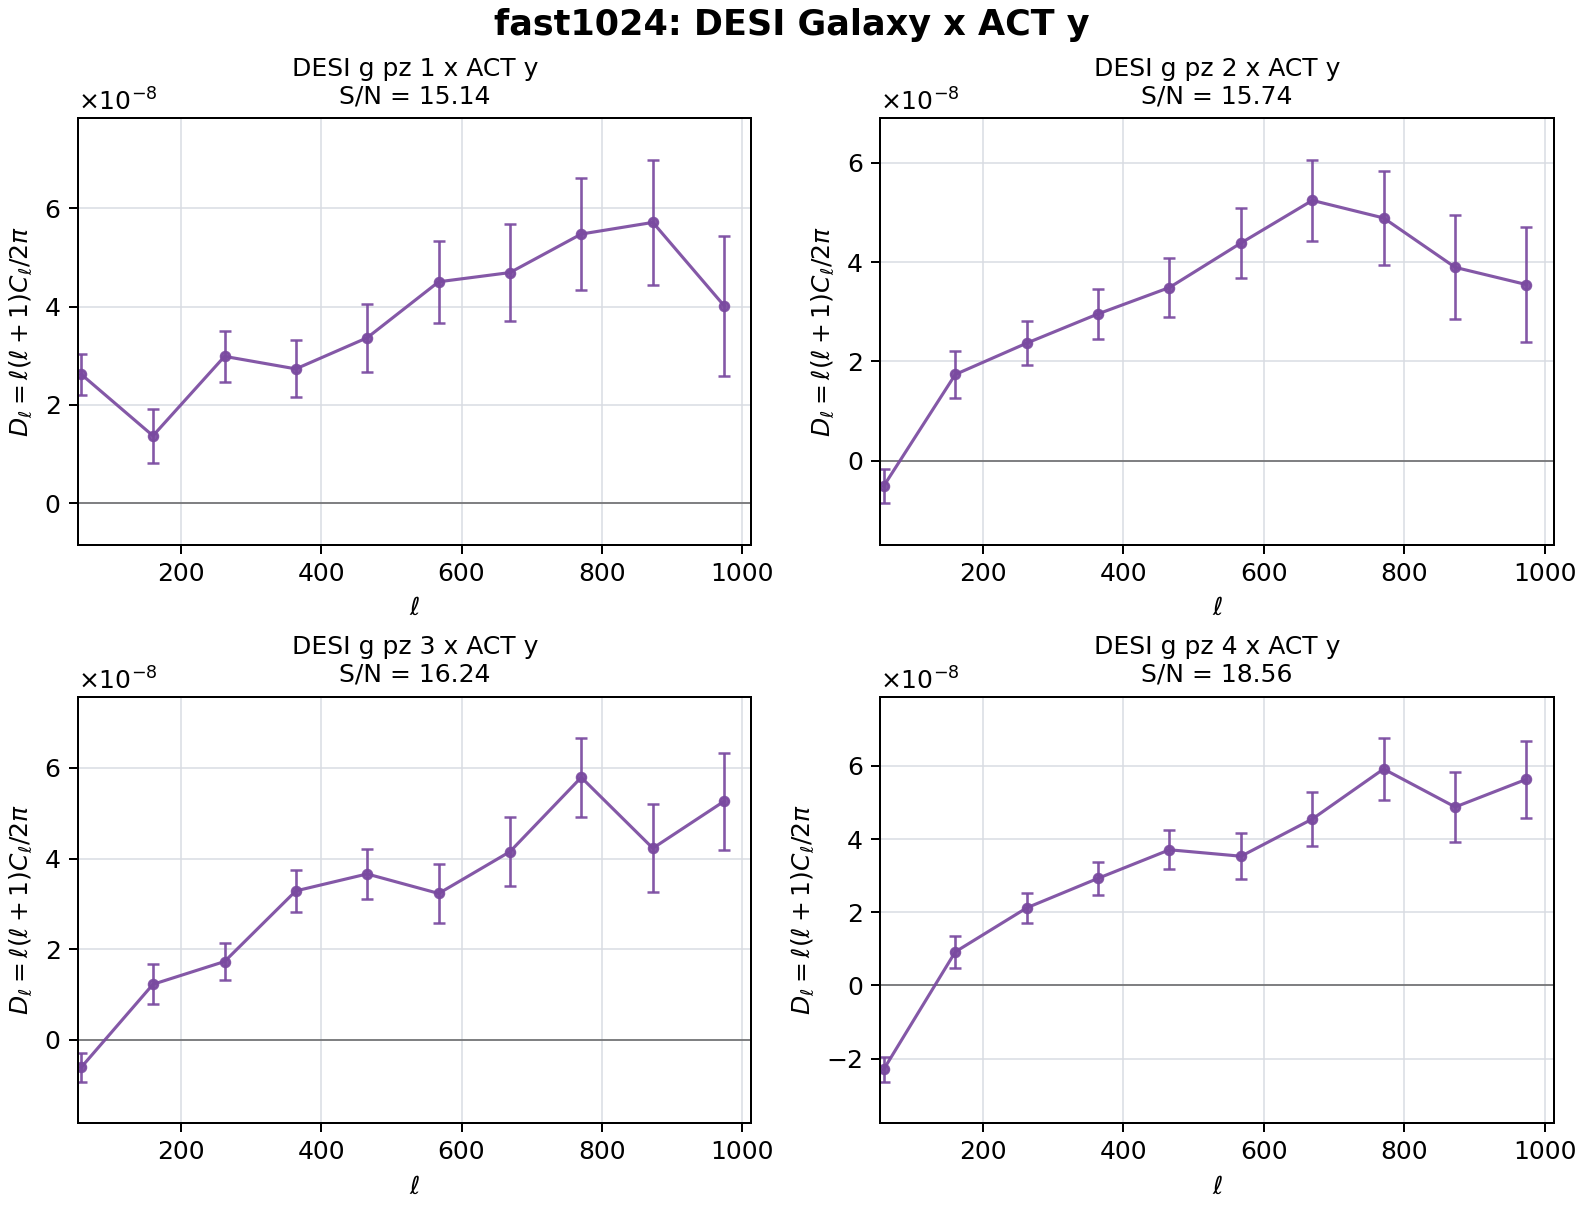

### fast1024_spectra_desi_g_des_shear_E_Dell.png

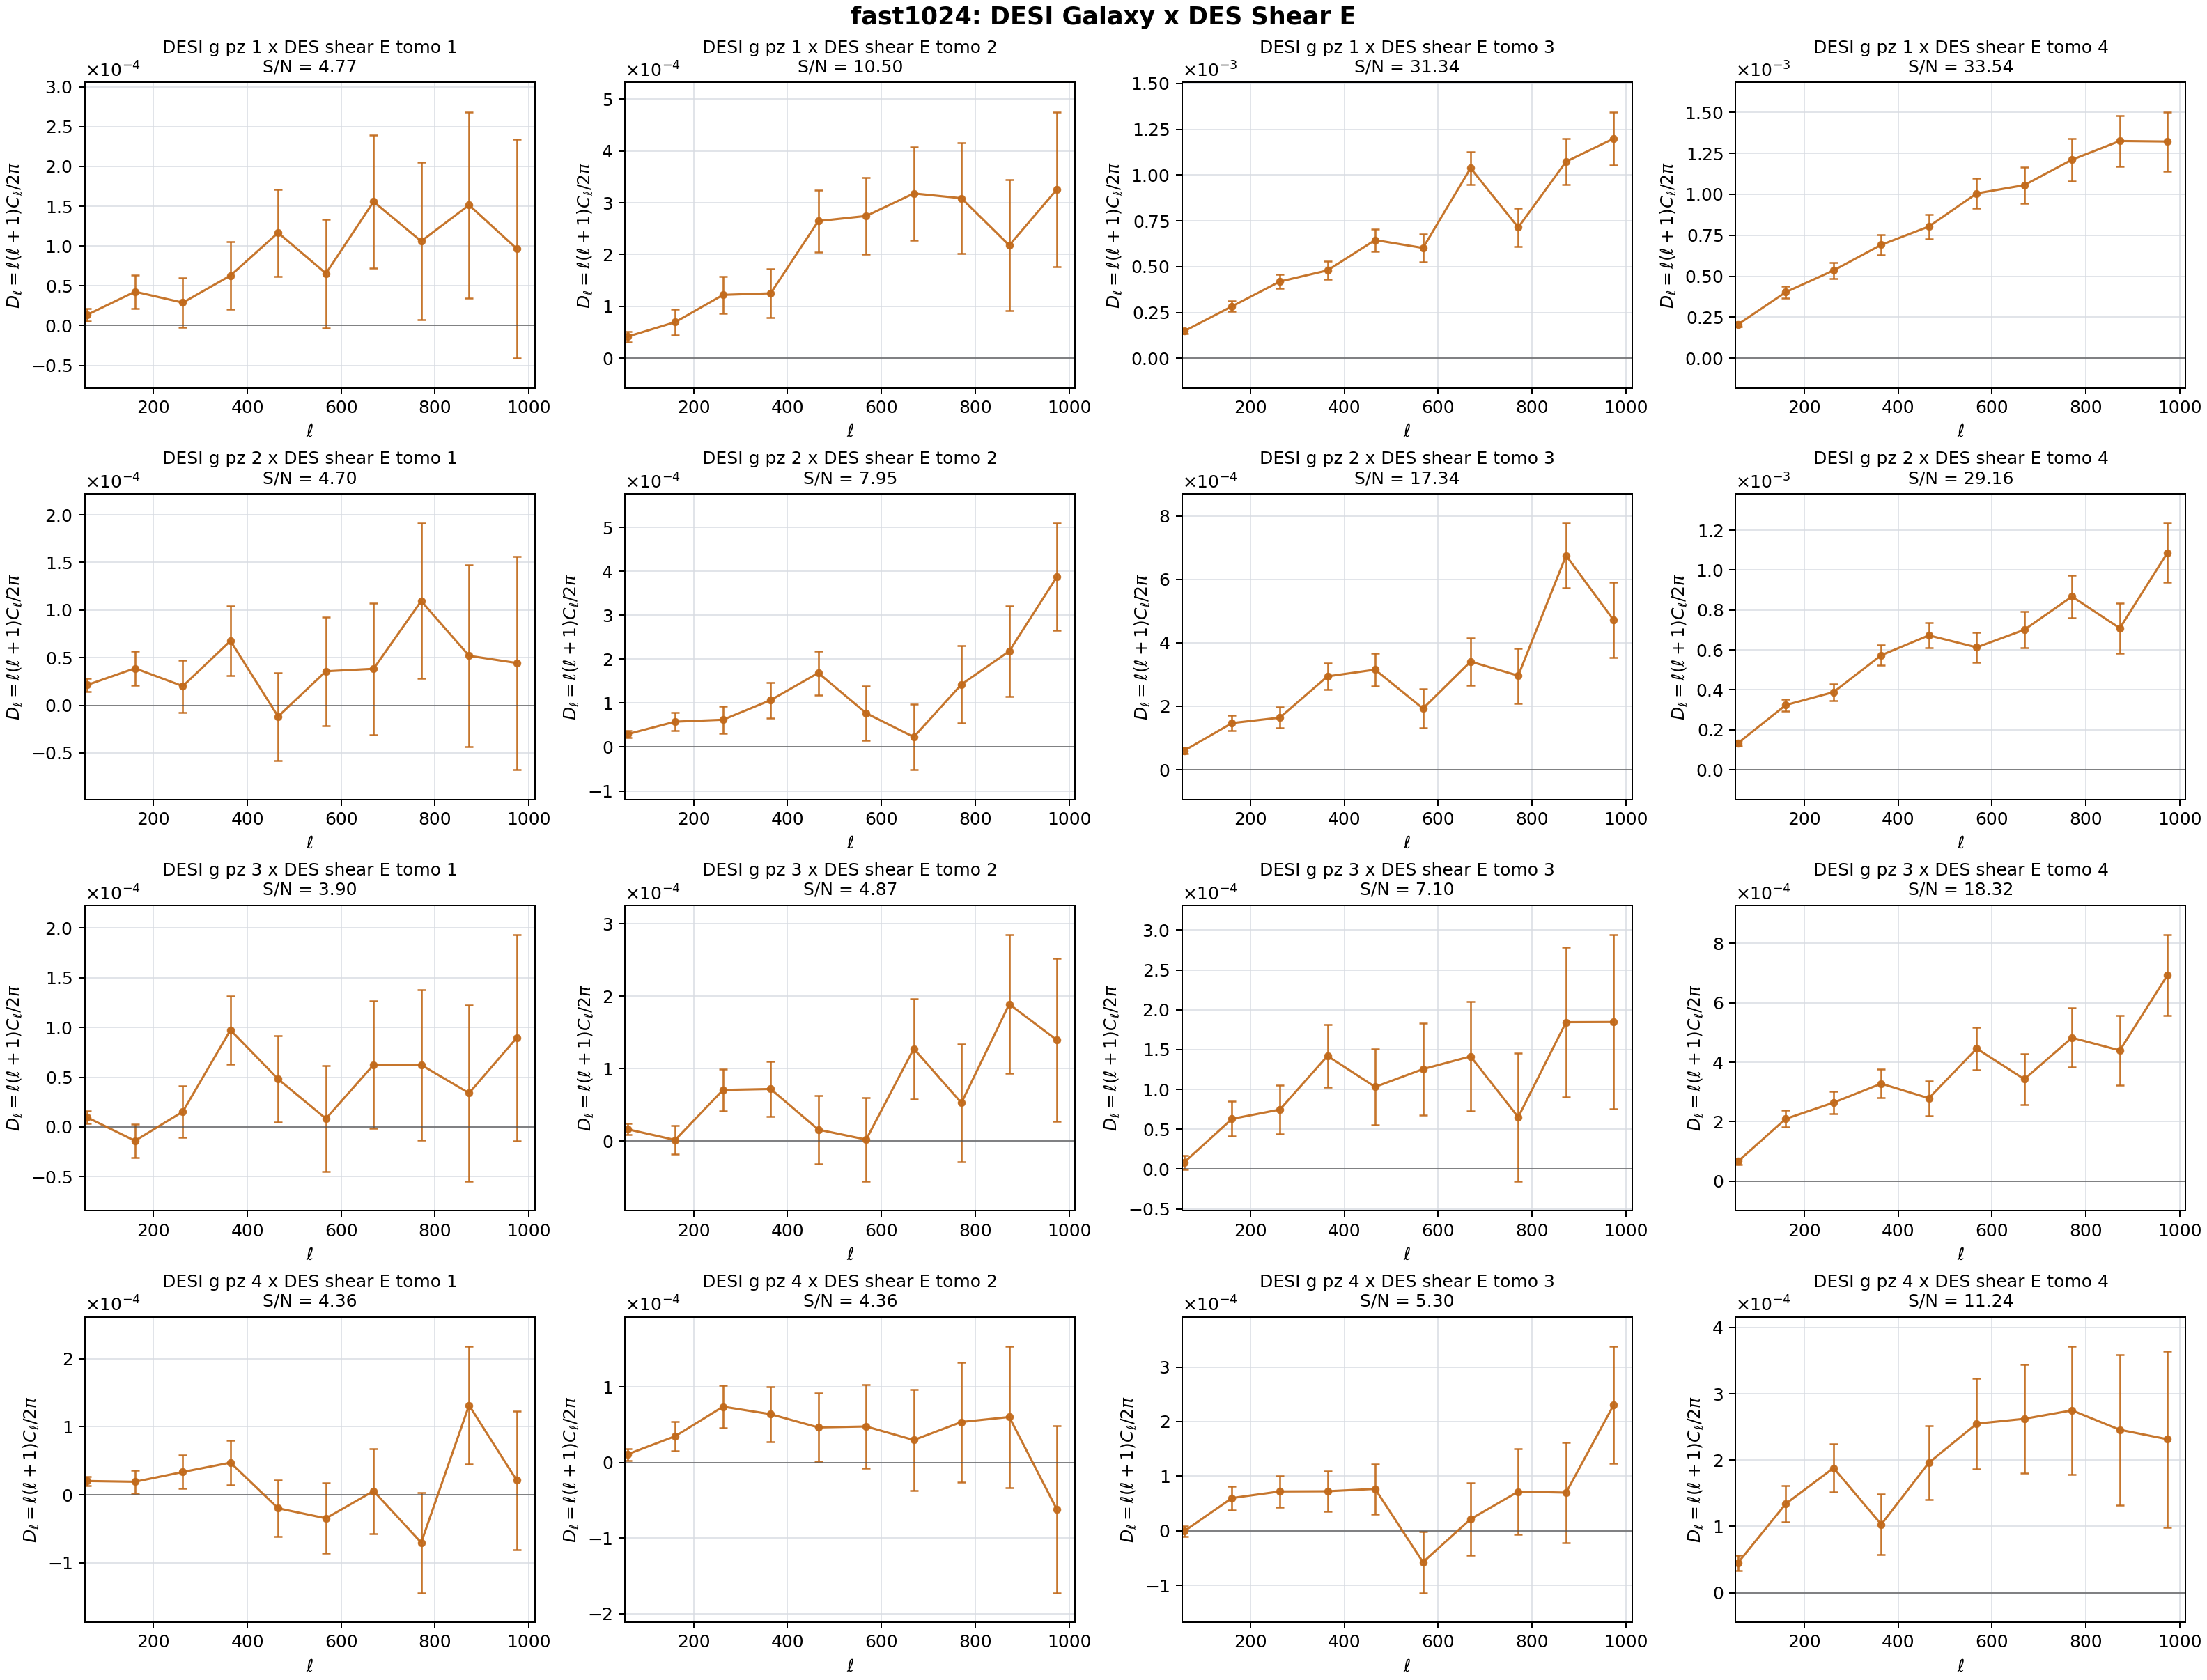

### fast1024_spectra_desi_g_act_kappa_Dell.png

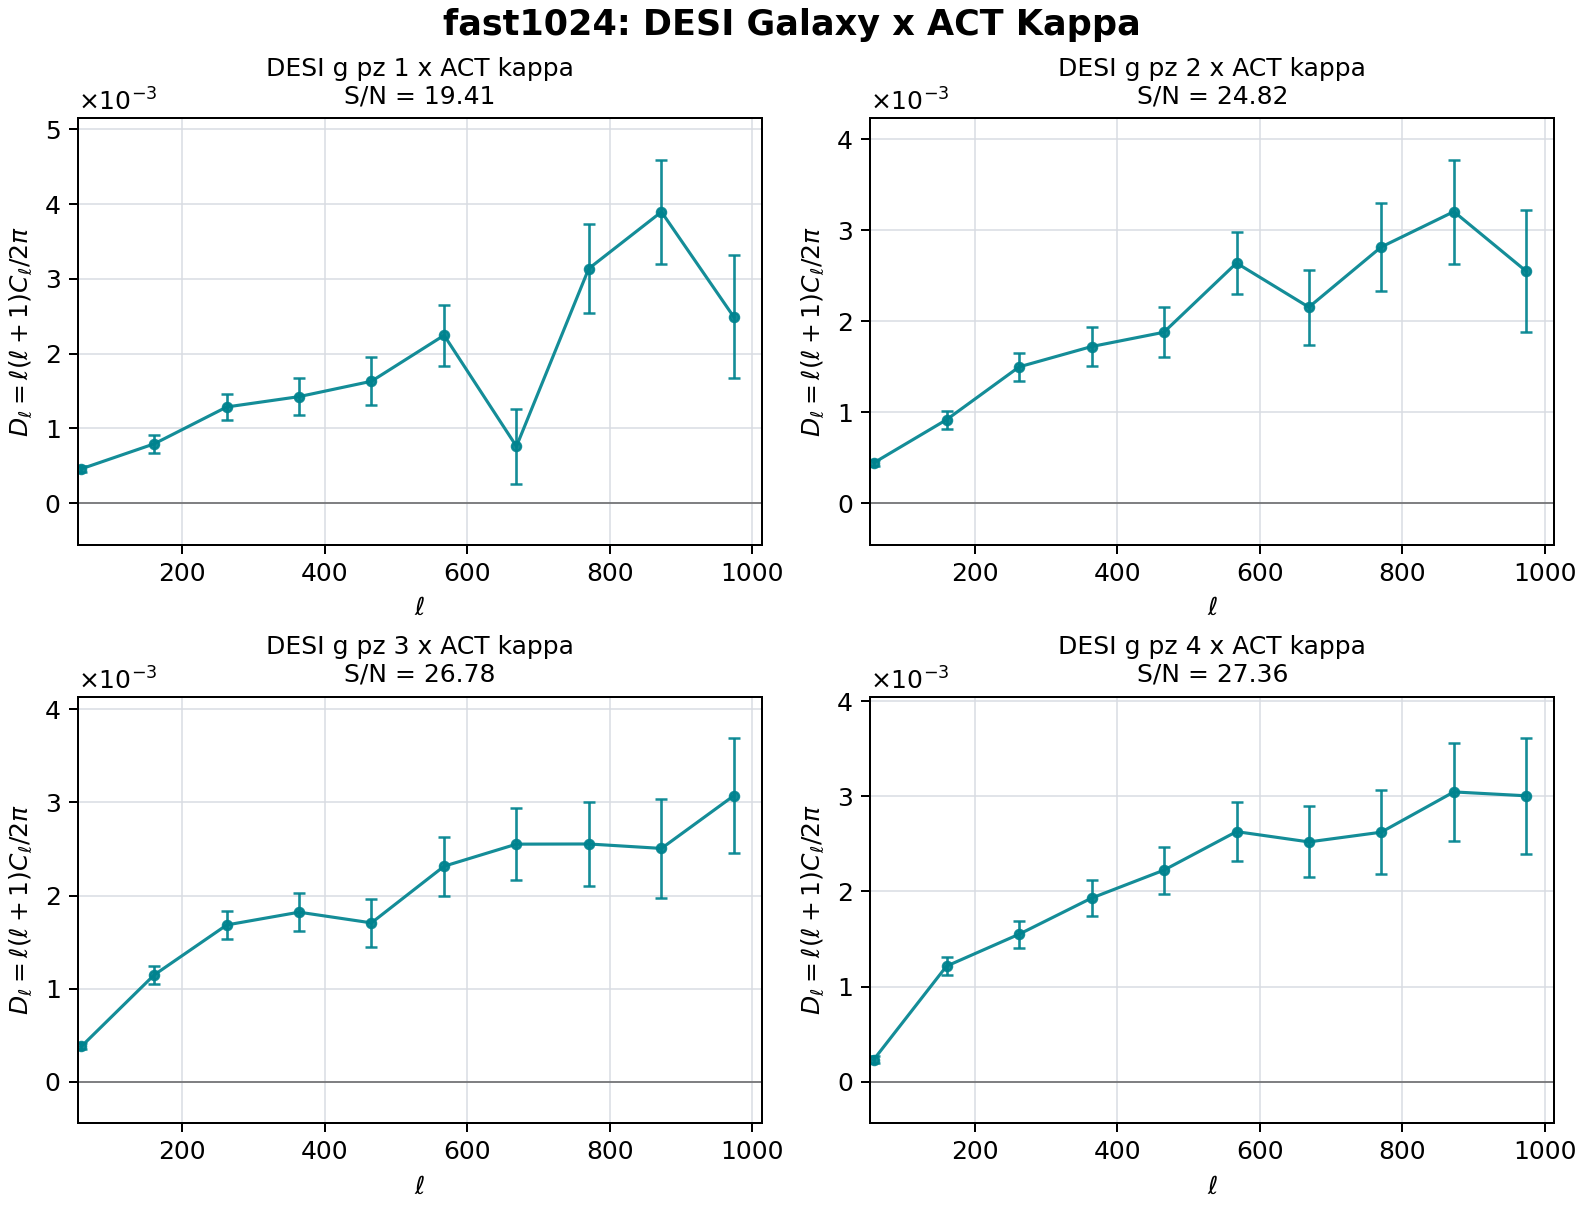

### fast1024_spectra_desi_pi_act_T_Dell.png

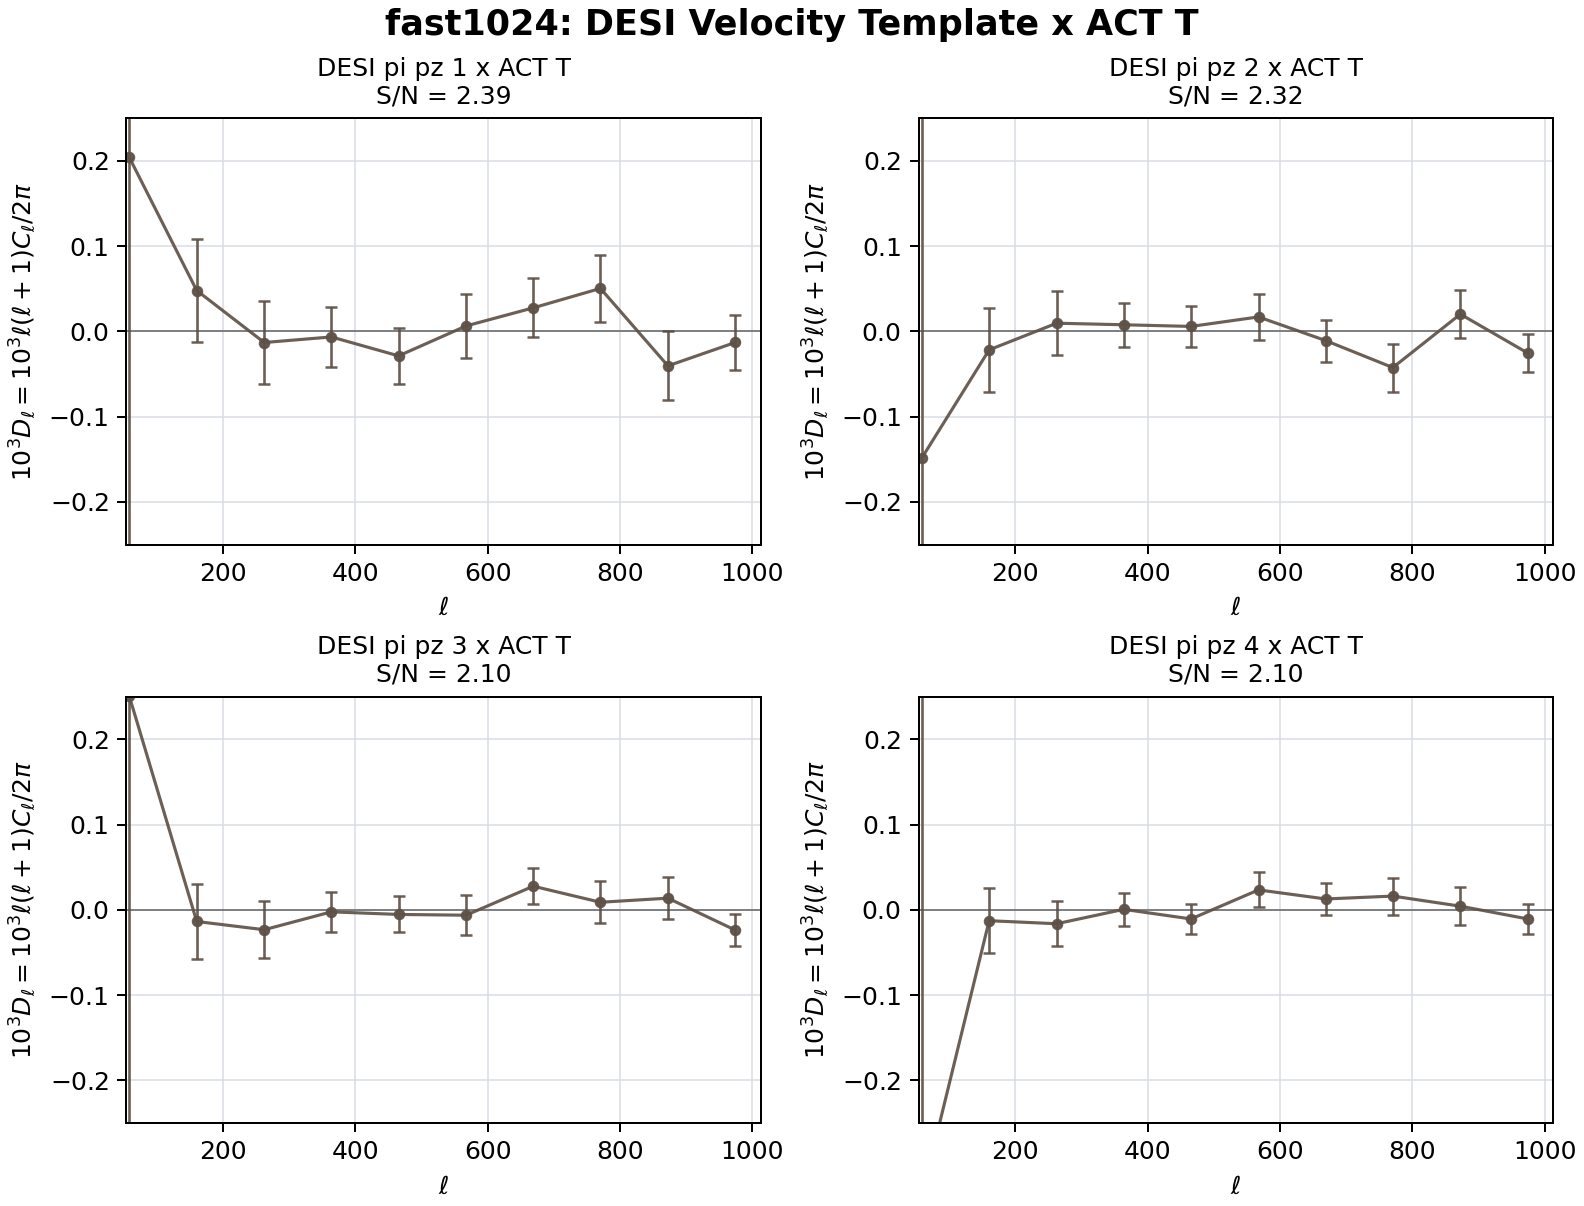

### fast1024_joint_covariance_matrix.png

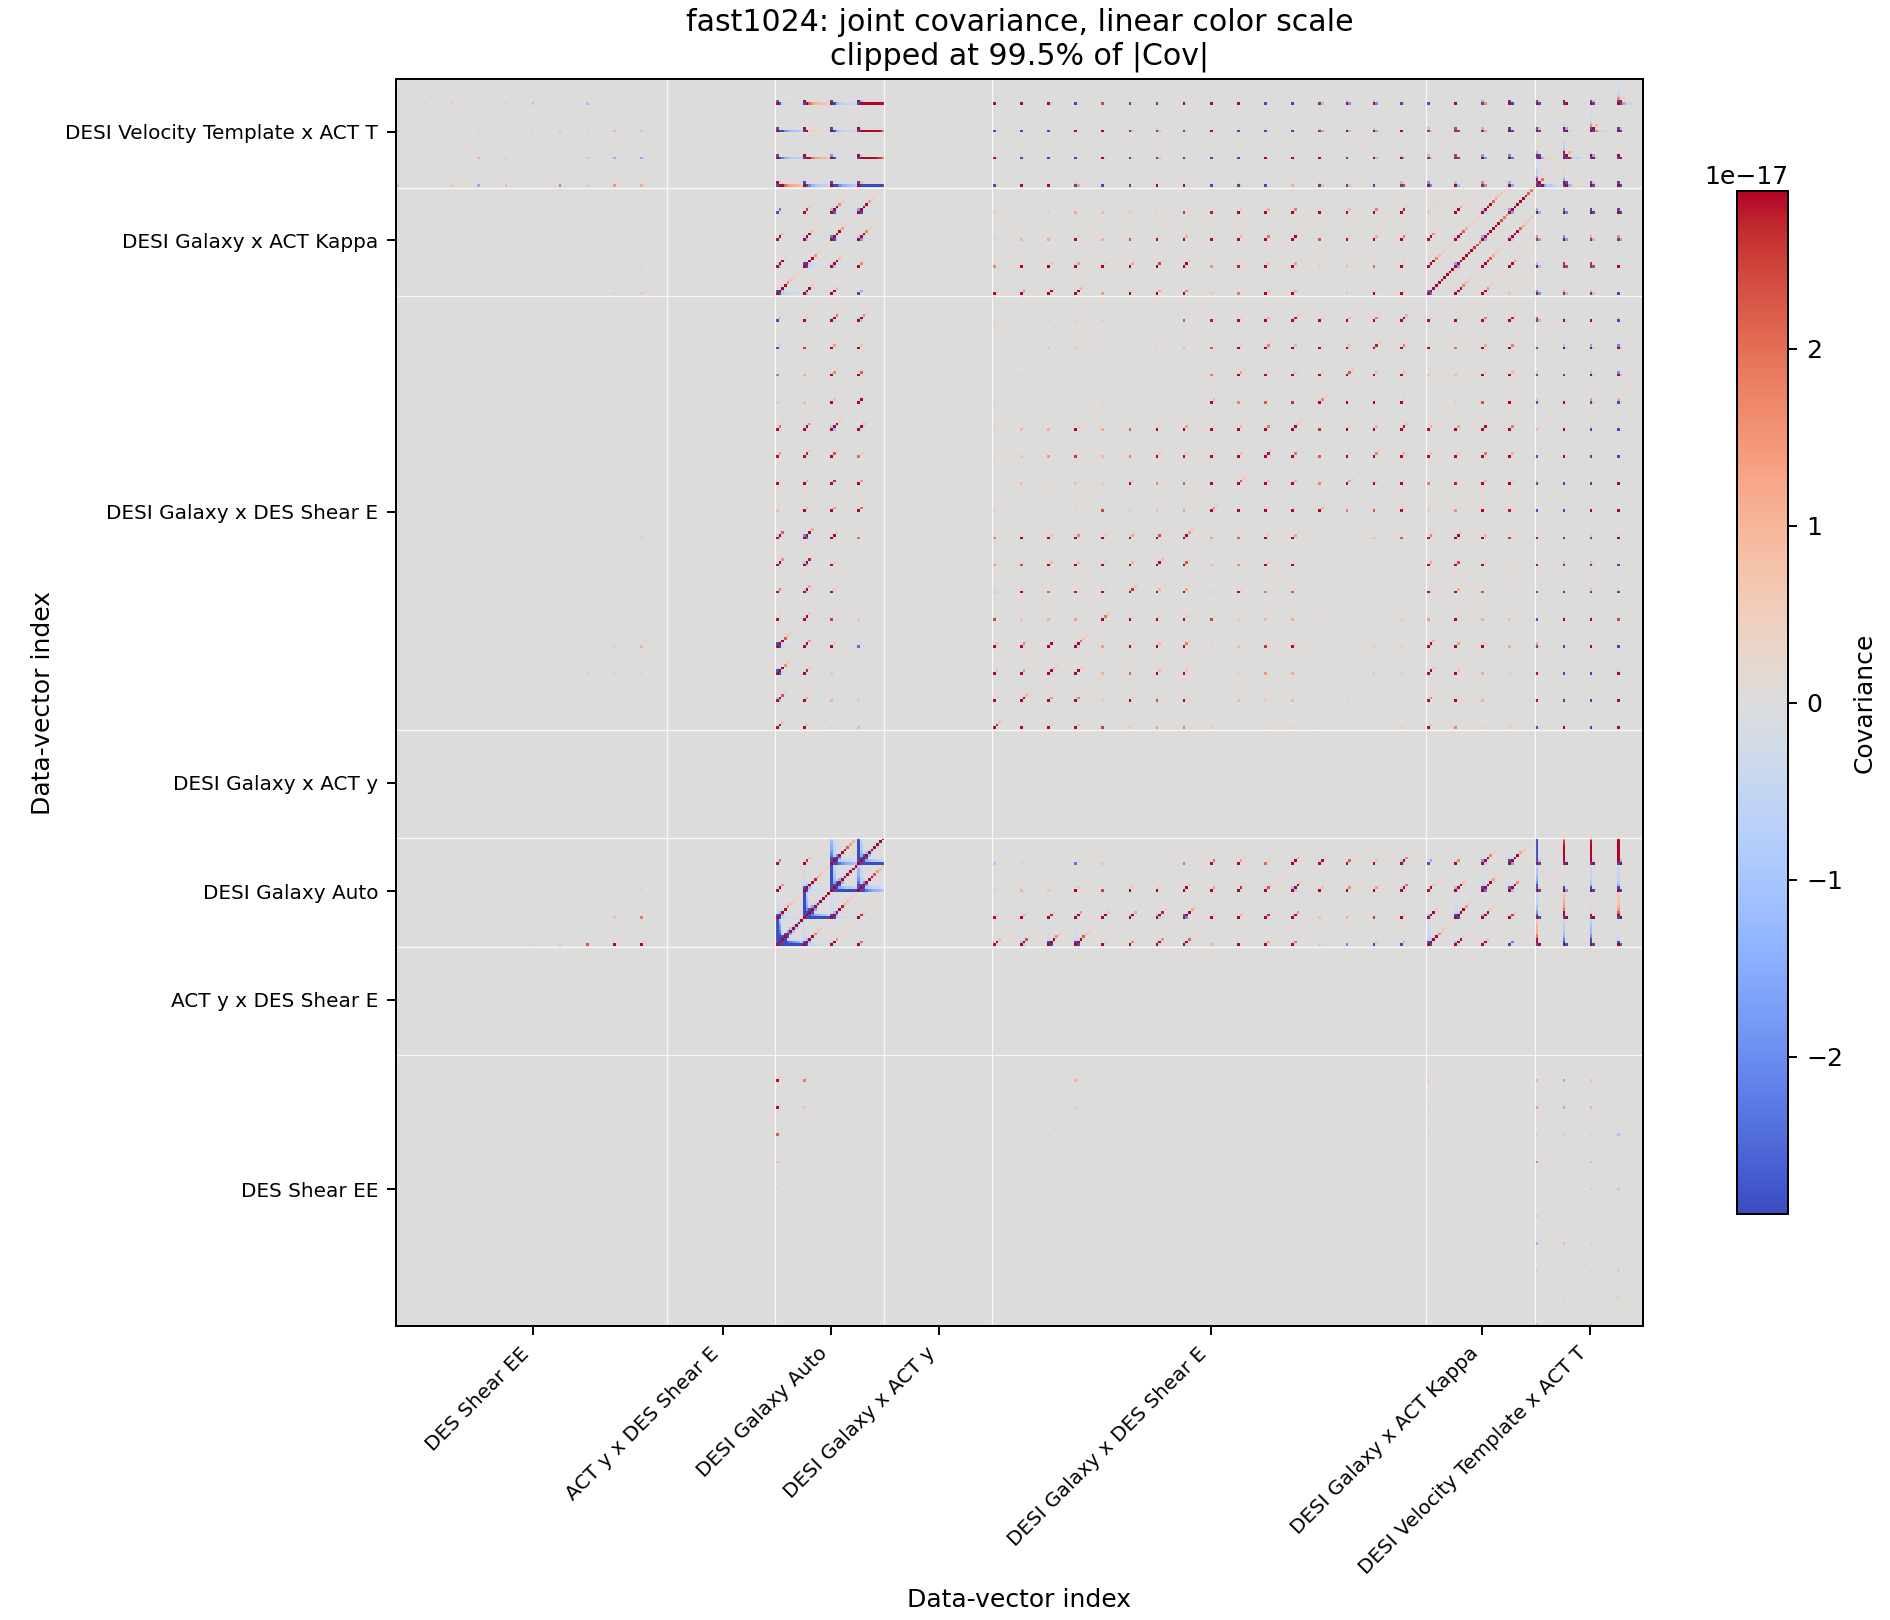

### fast1024_joint_correlation_matrix.png

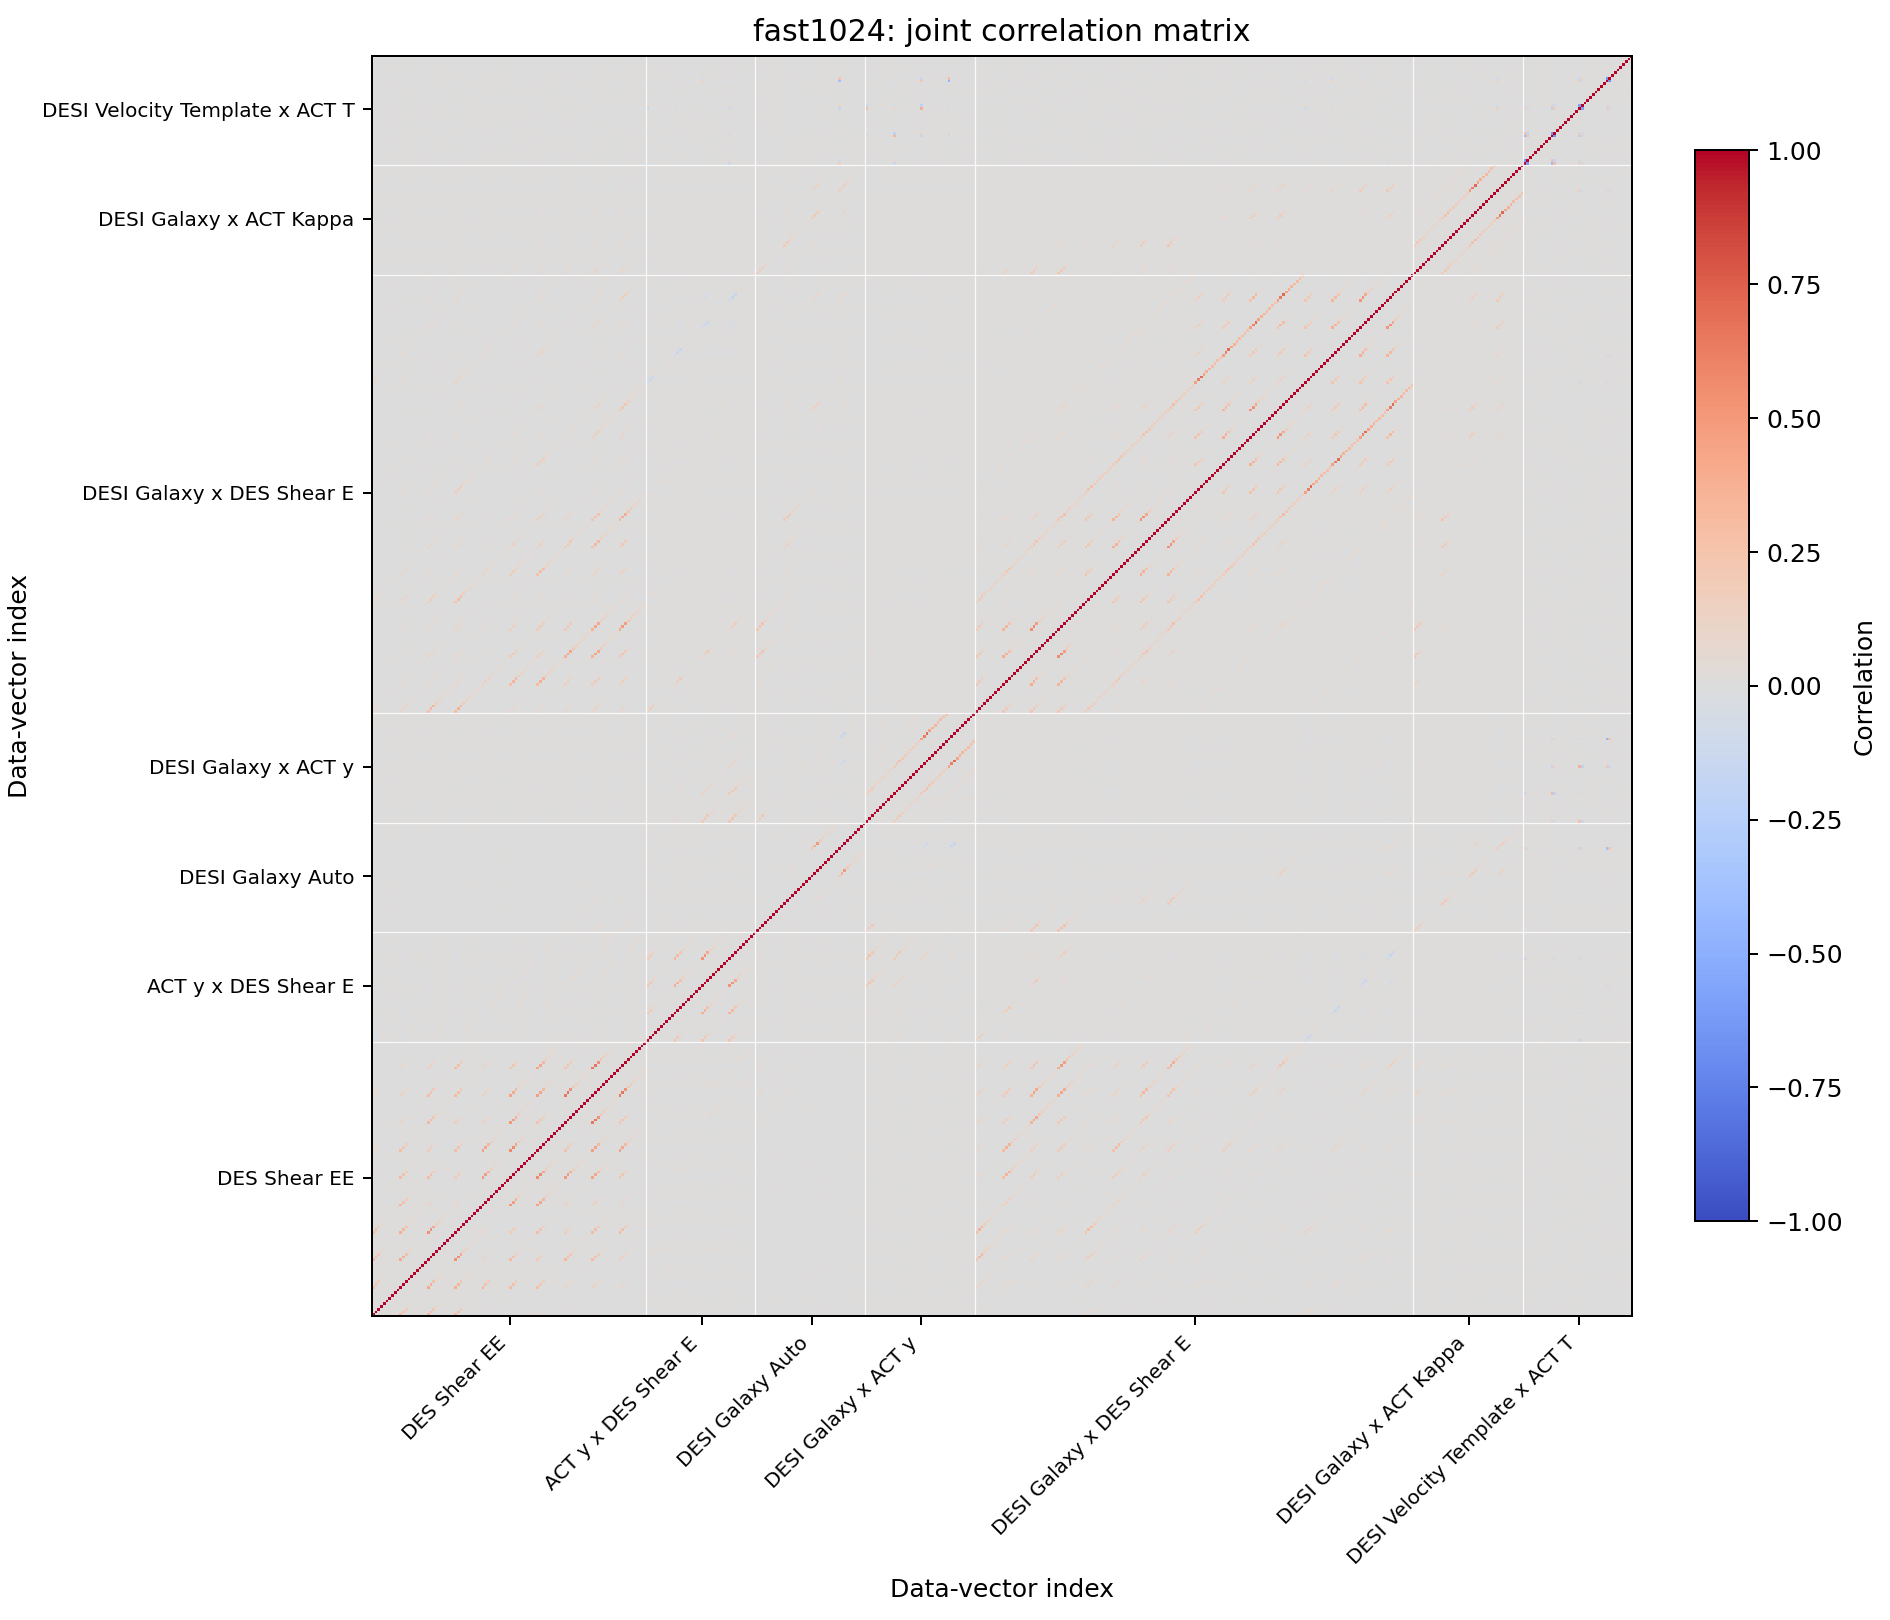

### fast1024_joint_covariance_diagonal_errors.png

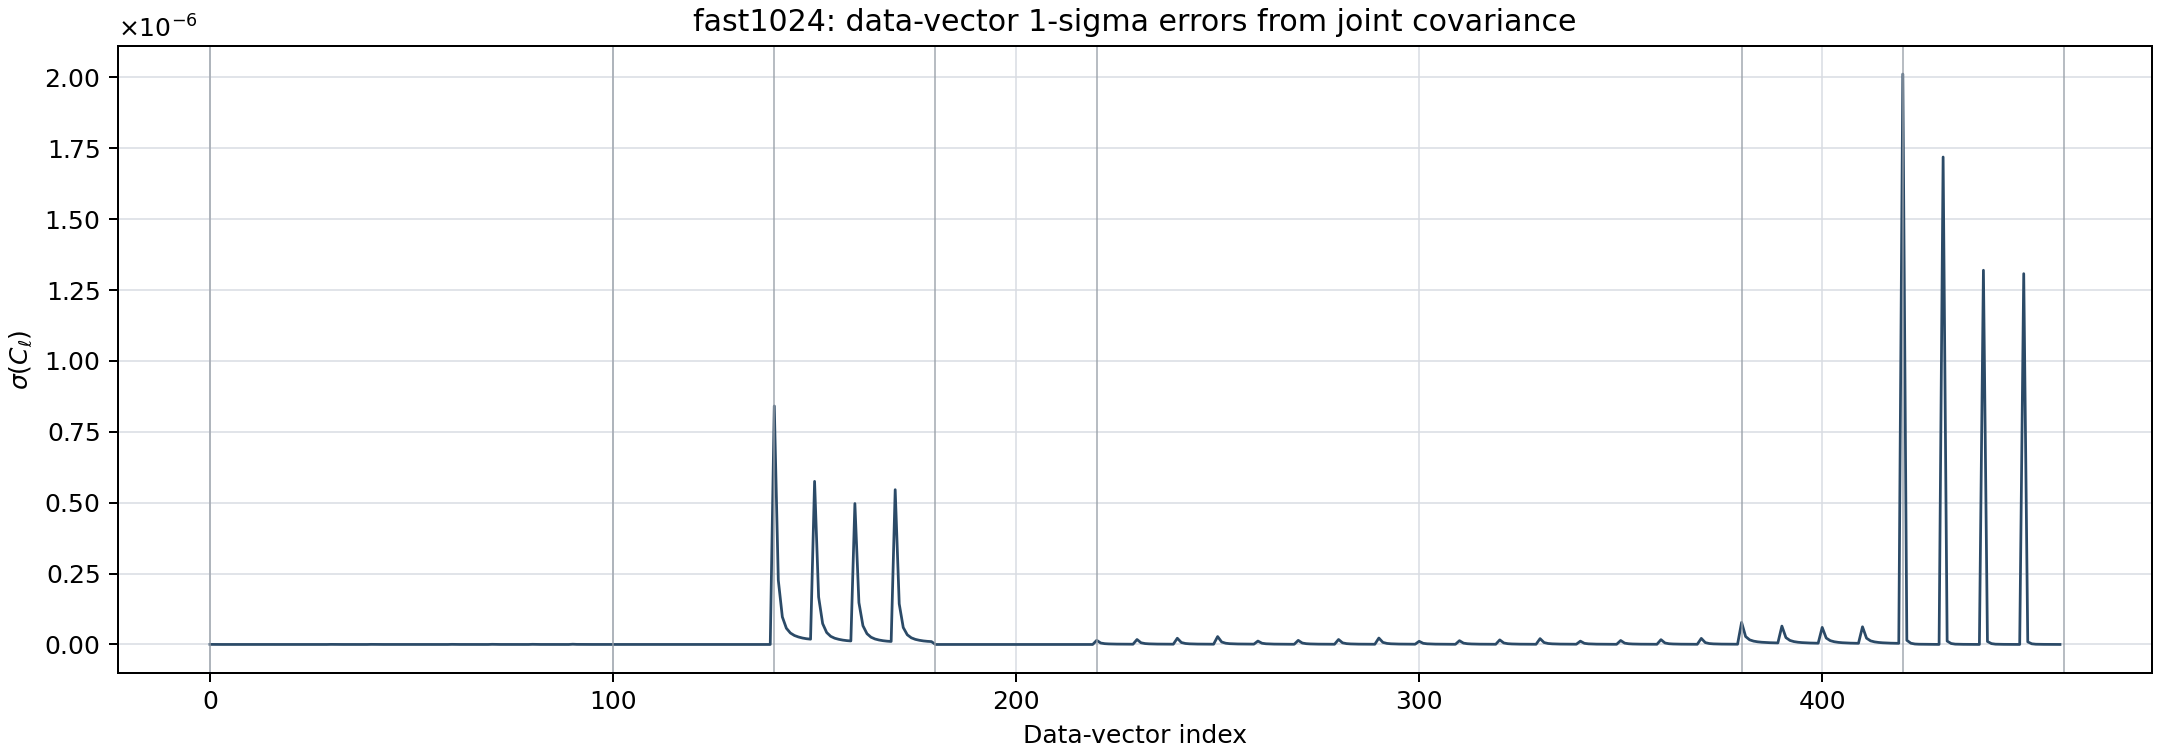

In [5]:
for path in outputs:
    if path.suffix.lower() == '.png':
        display(Markdown(f'### {path.name}'))
        display(Image(filename=str(path)))